In [62]:
using Revise
using ConjugateHeatTransfer
using CairoMakie
using LinearAlgebra
using QuadGK
using PolygonOps
using StaticArrays
using BenchmarkTools

In [63]:
# Parameters
Pe = 1;
N_laurent = 32;
N_bie = 32; # number of points per slit for BIE
solve_quad(args...) = quadgk(args...; atol=1e-10, rtol=1e-10)[1];
plot_quad(args...) = quadgk(args...; atol=1e-5, rtol=1e-5)[1];

# Bodies
zc = 0.0;
bodyshape(θ) = exp(im*θ) * (1 + 0.3*cos(2*θ-1) + 0.1*sin(5*θ));
bodytemp(θ) = (1 + 0.5*sin(5*θ));
bodies = [DirichletBody(zc, bodyshape, bodytemp)];

In [64]:
# Solve potential flow
t0 = time();
W = aaa_potential_flow(bodies, N_laurent);
println("Solved potential flow (", round(time()-t0, digits=3), " s)");
t0 = time();
reparametrize!(bodies, W; atol=1e-6);
println("Joukowsky reparametrization done (", round(time()-t0, digits=3), " s)");

N samples: 32, AAA poles: 8
N samples: 64, AAA poles: 16
N samples: 128, AAA poles: 31
N samples: 256, AAA poles: 41
N samples: 512, AAA poles: 42
N samples: 1024, AAA poles: 41
  Q shape: (438, 148)
  Fitting error: 2.635114348947809e-13
Solved potential flow (1.648 s)
  w coeffs: 62
  dθ coeffs: 1055
  zη coeffs: 571
  Tη coeffs: 863
Joukowsky reparametrization done (0.375 s)


In [65]:
# Panels
panels = [DirichletPanel(body) for body in bodies];
t0 = time();
solve_densities!(panels, N_bie; Pe=Pe, atol=1e-4, quadrature=solve_quad);
println("Densities solved (", round(time()-t0, digits=3), " s)");

  g coeffs: 117
size(M) = (64, 32)
cond(M) = 37.661854247439294
Densities solved (0.849 s)


In [66]:
# Evaluate on a grid
gridsize = 300
Lz = 3.1
x = collect(LinRange(-Lz, Lz, gridsize));
y = collect(LinRange(-Lz, Lz, gridsize));
z = x' .+ im*y;

# Evaluate flow
t0 = time();
w = reshape(W(vec(z)), size(z));
println("Flow evaluated (", round(time()-t0, digits=3), " s)");

# Mask interiors before evaluating temperature
φ = real(w);
ψ = imag(w);
function check_inside(body, z)
    poly = body.zθ.(LinRange(0, 2π, 100))
    poly[end] = poly[1]
    poly = [[real(z), imag(z)] for z in poly]
    return inpolygon([real(z), imag(z)], poly; in=true, on=false, out=false)
end
for body in bodies
    check_body(z) = check_inside(body, z)
    interior = check_body.(z)
    φ[interior] .= -999
    ψ[interior] .= -999
end

# Evaluate temperature
t0 = time();
T = EvaluateSystem(φ, ψ, panels; Pe=Pe, quadrature=plot_quad);
println("Temperature evaluated (", round(time()-t0, digits=3), " s)");

# Mask interiors
for body in bodies
    check_body(z) = check_inside(body, z)
    interior = check_body.(z)
    φ[interior] .= NaN
    ψ[interior] .= body.ψ
    T[interior] .= NaN
end

# Evaluate in w domain
gridsize = 300
Lw = 5.1
φw = collect(LinRange(-Lw, Lw, gridsize));
ψw = collect(LinRange(-Lw, Lw, gridsize));
ww = φw' .+ im*ψw;
Tw = EvaluateSystem(real(ww), imag(ww), panels; Pe=Pe, quadrature=plot_quad);

Flow evaluated (0.12 s)
Temperature evaluated (19.793 s)


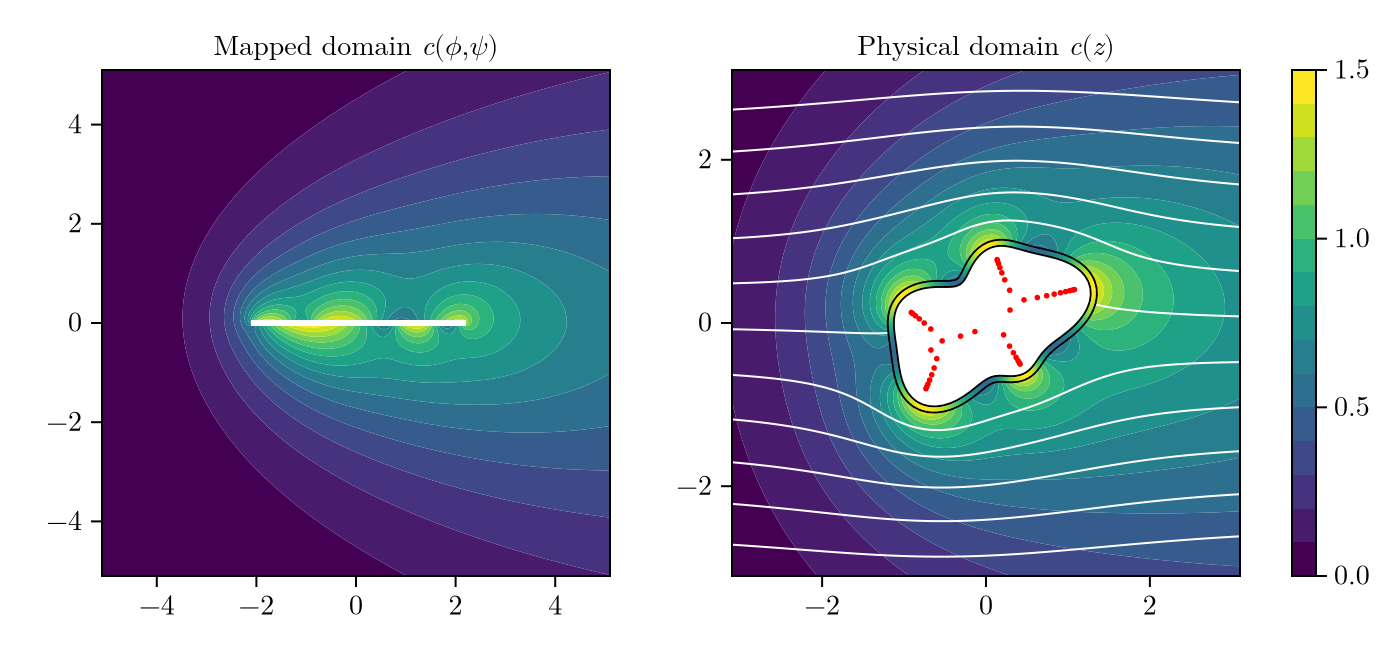

In [67]:
# Plot
fig = Figure(size=(700, 325));
set_theme!(theme_latexfonts());

# Levels
T_levels = LinRange(0, 1.5, 16);
ψ_levels = collect(LinRange(-5, 5, 21)) .+ bodies[1].ψ;

# Left panel: T(w)
ax = Axis(fig[1,1], aspect=DataAspect(), title=L"Mapped domain $c(\phi,\psi)$");
xlims!(ax, -Lw, Lw)
ylims!(ax, -Lw, Lw)
# Temperature contours
contourf!(ax, φw, ψw, Tw', levels=T_levels, nan_color=:black);
# Streamlines
#contour!(ax, φw, ψw, imag(ww)', levels=ψ_levels, color=:white, linewidth=1);
# Body slits
for body in bodies
    lines!(ax, [body.φmin, body.φmax], [0, 0], color=:white, linewidth=3)
end

# Right panel: T(z)
ax = Axis(fig[1,2], aspect=DataAspect(), title=L"Physical domain $c(z)$");
xlims!(ax, -Lz, Lz)
ylims!(ax, -Lz, Lz)
# Background for body interiors
poly!(ax, [(-Lz, -Lz), (Lz, -Lz), (Lz, Lz), (-Lz, Lz)], color=:white, rasterize=true)
# Temperature contours
co = contourf!(ax, x, y, T', levels=T_levels, nan_color=:black);
# Streamlines
contour!(ax, x, y, ψ', levels=ψ_levels, color=:white, linewidth=1);
# Bodies
colorrange = (minimum(co._computed_levels.val), maximum(co._computed_levels.val));
θp = LinRange(0, 2π, 100);
for body in bodies
    boundary = body.zθ.(θp)
    temp = body.Tθ.(θp)
    lines!(ax, real(boundary), imag(boundary), color=:black, linewidth=4, colorrange=colorrange)
    lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=2, colorrange=colorrange)
    # Replot with shift to get rid of color artifacts
    boundary = body.zθ.(θp.+π/100)
    temp = body.Tθ.(θp.+π/100)
    lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=2, colorrange=colorrange)
    # AAA poles
    scatter!(ax, real(body.aaa_poles), imag(body.aaa_poles), color=:red, markersize=4)
end

Colorbar(fig[1,3], co);
save("fig_potato.pdf", fig);
fig